<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import pandas as pd
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
drive.mount('/content/drive')
medical_df = pd.read_csv("drive/MyDrive/DATA LOVE/medical-charges.csv")
non_smoker_df = medical_df[medical_df.smoker == 'no']

Mounted at /content/drive


In [3]:
X = non_smoker_df['age'].values
y = non_smoker_df['charges'].values

def rmse(targets, predictions):
    return np.sqrt(np.mean((targets - predictions) ** 2))

In [4]:
# 1. Метод найменших квадратів

X_b = np.c_[np.ones(X.shape[0]), X]  # додаємо стовпець одиниць для b

theta_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
b_ols, w_ols = theta_ols

predictions_ols = X_b @ theta_ols
rmse_ols = rmse(y, predictions_ols)

print(f"w = {w_ols:.4f}, b = {b_ols:.4f}")
print(f"RMSE = {rmse_ols:.4f}\n")

w = 267.2489, b = -2091.4206
RMSE = 4662.5058



In [5]:
X_2d = X.reshape(-1, 1)
print(f"X форма: {X.shape} → {X_2d.shape}\n")


X форма: (1064,) → (1064, 1)



In [6]:
# 2. Стандартизація X (z-score нормалізація)

X_mean, X_std = X_2d.mean(), X_2d.std()
X_scaled = (X_2d - X_mean) / X_std

print(f"До масштабування: X в діапазоні [{X_2d.min()}, {X_2d.max()}]")
print(f"Після масштабування: X в діапазоні [{X_scaled.min():.2f}, {X_scaled.max():.2f}]\n")

def gradient_descent(X_input, y, lr, epochs=1000):
    m = len(y)
    X_b = np.c_[np.ones(m), X_input]
    theta = np.zeros(2)
    history = []

    for _ in range(epochs):
        gradients = (2/m) * X_b.T @ (X_b @ theta - y)
        theta -= lr * gradients
        history.append(rmse(y, X_b @ theta))

    return theta, history

learning_rates = [0.01, 0.001, 0.001]
gd_results = {}

for lr in learning_rates:
    theta, history = gradient_descent(X_scaled, y, lr)
    gd_results[lr] = {'theta': theta, 'history': history}
    print(f"=== GD (scaled) lr={lr} ===")
    print(f"theta (scaled) = {theta}")
    print(f"RMSE = {history[-1]:.4f}\n")


До масштабування: X в діапазоні [18, 64]
Після масштабування: X в діапазоні [-1.52, 1.75]

=== GD (scaled) lr=0.01 ===
theta (scaled) = [8434.26828366 3762.00690212]
RMSE = 4662.5058

=== GD (scaled) lr=0.001 ===
theta (scaled) = [7295.09787802 3253.89324192]
RMSE = 4826.4737

=== GD (scaled) lr=0.001 ===
theta (scaled) = [7295.09787802 3253.89324192]
RMSE = 4826.4737



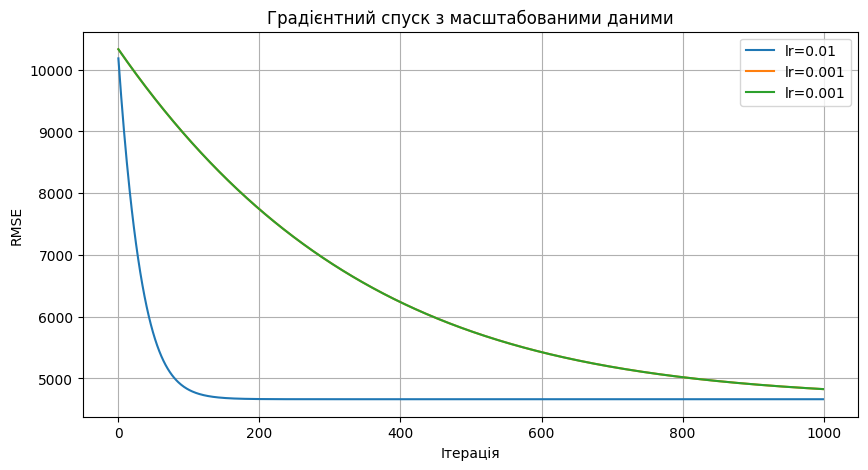

In [7]:
# Графік помилки в залежності від ітерації для кожного lr

plt.figure(figsize=(10, 5))
for lr in learning_rates:
    plt.plot(gd_results[lr]['history'], label=f'lr={lr}')
plt.xlabel('Ітерація')
plt.ylabel('RMSE')
plt.title('Градієнтний спуск з масштабованими даними')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Обираємо найкращий learning rate (найменший фінальний RMSE)

best_lr = min(learning_rates, key=lambda lr: gd_results[lr]['history'][-1])
theta_scaled = gd_results[best_lr]['theta']

b_scaled, w_scaled = theta_scaled
w_gd = w_scaled / X_std
b_gd = b_scaled - (w_scaled * X_mean / X_std)

predictions_gd = w_gd * X_2d.flatten() + b_gd
rmse_gd = rmse(y, predictions_gd)

print(f"Найкращий learning rate (на масштабованих даних): {best_lr}")
print(f"Коефіцієнти у оригінальному масштабі: w = {w_gd:.4f}, b = {b_gd:.4f}")
print(f"RMSE = {rmse_gd:.4f}")

Найкращий learning rate (на масштабованих даних): 0.01
Коефіцієнти у оригінальному масштабі: w = 267.2489, b = -2091.4206
RMSE = 4662.5058


In [9]:
# 3.Scikit-learn LinearRegression

X_frame = non_smoker_df[['age']]

print(X_frame.shape)

model = LinearRegression()
model.fit(X_frame, y)

w_sklearn = model.coef_[0]
b_sklearn = model.intercept_

predictions_sklearn = model.predict(X_frame)
rmse_sklearn = rmse(y, predictions_sklearn)

print(f"w = {w_sklearn:.4f}, b = {b_sklearn:.4f}")
print(f"RMSE = {rmse_sklearn:.4f}\n")

(1064, 1)
w = 267.2489, b = -2091.4206
RMSE = 4662.5058



In [10]:
# Підсумкова таблиця

print(f"{'Метод':<15} {'w':>10} {'b':>10} {'RMSE':>10}")
print(f"{'МНК':<15} {w_ols:>10.4f} {b_ols:>10.4f} {rmse_ols:>10.4f}")
print(f"{'GD (' + str(best_lr) + ')':<15} {w_gd:>10.4f} {b_gd:>10.4f} {rmse_gd:>10.4f}")
print(f"{'Scikit-learn':<15} {w_sklearn:>10.4f} {b_sklearn:>10.4f} {rmse_sklearn:>10.4f}")

Метод                    w          b       RMSE
МНК               267.2489 -2091.4206  4662.5058
GD (0.01)         267.2489 -2091.4206  4662.5058
Scikit-learn      267.2489 -2091.4206  4662.5058


Масштабування ознак (стандартизація) є критично важливим для градієнтного спуску, коли вхідні змінні мають різні порядки величин (вік ~18-64 проти витрат ~тисячі). Без масштабування градієнт по параметру b домінує над градієнтом по w, що змушує використовувати дуже малий learning rate (0.0001) і призводить до повільної, неповної збіжності за обмежену кількість ітерацій. Після стандартизації X найкращим виявився lr=0.01, який дав збіжність до точного аналітичного розв'язку (ідентичного МНК і scikit-learn) за ті самі 1000 ітерацій.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


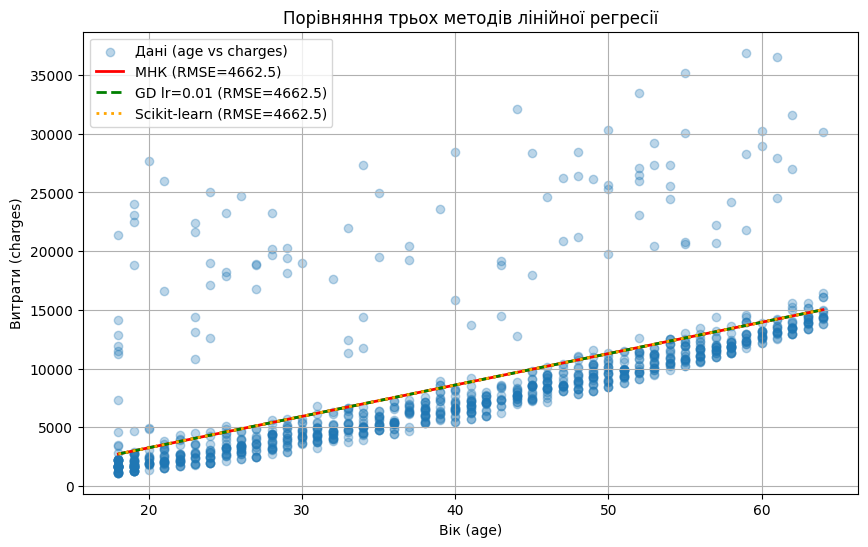

In [13]:
x_line = np.linspace(X.min(), X.max(), 100)
X_line_b = np.c_[np.ones(100), x_line]

# Define theta_gd from the previously calculated b_gd and w_gd
theta_gd = np.array([b_gd, w_gd])

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.3, label='Дані (age vs charges)')

plt.plot(x_line, X_line_b @ theta_ols, label=f'МНК (RMSE={rmse_ols:.1f})',
         linewidth=2, color='red')
plt.plot(x_line, X_line_b @ theta_gd, label=f'GD lr={best_lr} (RMSE={rmse_gd:.1f})',
         linewidth=2, color='green', linestyle='--')
plt.plot(x_line, model.predict(x_line.reshape(-1, 1)),
         label=f'Scikit-learn (RMSE={rmse_sklearn:.1f})',
         linewidth=2, color='orange', linestyle=':')

plt.xlabel('Вік (age)')
plt.ylabel('Витрати (charges)')
plt.title('Порівняння трьох методів лінійної регресії')
plt.legend()
plt.grid(True)
plt.show()

Усі три методи дали однаковий результат з точністю до 4 знаків. Це підтверджує, що масштабування має велике значення.

Масштабування дало точну збіжність — GD тепер знаходить той самий глобальний мінімум, що й аналітичний МНК. lr=0.01 виявився оптимальним з трьох протестованих (0.1, 0.01, 0.001) — досить великий для швидкої збіжності, але не настільки великий, щоб розходитись.

## Висновок

Масштабування ознак (стандартизація) є критично важливим для градієнтного спуску, коли вхідні змінні мають різні порядки величин (вік ~18-64 проти витрат ~тисячі). Без масштабування градієнт по параметру b домінує над градієнтом по w, що змушує використовувати дуже малий learning rate (0.0001) і призводить до повільної, неповної збіжності за обмежену кількість ітерацій. Після стандартизації X найкращим виявився lr=0.01, який дав збіжність до точного аналітичного розв'язку (ідентичного МНК і scikit-learn) за ті самі 1000 ітерацій.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [14]:
from sklearn.metrics import r2_score

smoker_df = medical_df[medical_df.smoker == 'yes']

In [15]:
smoker_df = medical_df[medical_df['smoker'] == 'yes']

X = smoker_df[['age']]
y = smoker_df['charges']

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

r2 = r2_score(y, predictions)
rmse = np.sqrt(np.mean((y - predictions) ** 2))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.1356
RMSE: 10711.0033


In [16]:
w = model.coef_[0]
b = model.intercept_
print(f"\nКоефіцієнт нахилу (w): {w:.4f}")
print(f"Вільний член (b): {b:.4f}")
print(f"Рівняння: charges = {w:.2f} * age + {b:.2f}")


Коефіцієнт нахилу (w): 305.2376
Вільний член (b): 20294.1281
Рівняння: charges = 305.24 * age + 20294.13


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


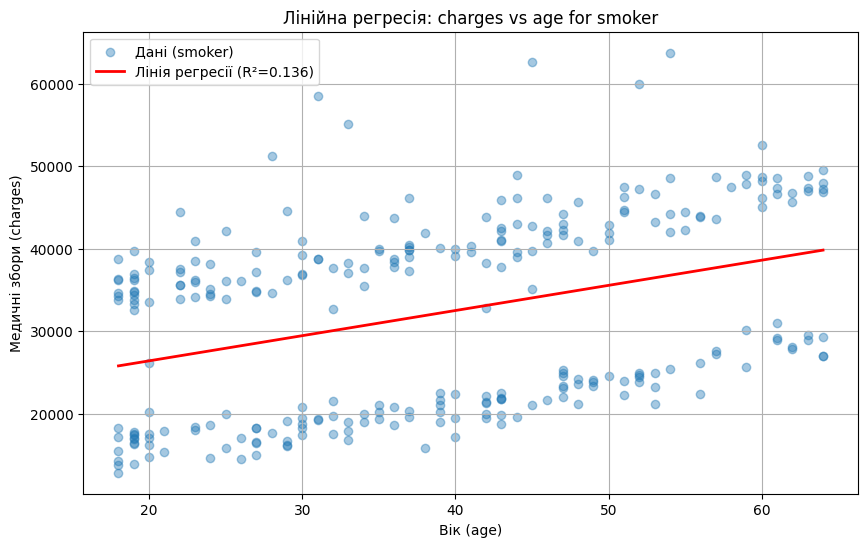

In [17]:
x_line = np.linspace(X['age'].min(), X['age'].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(X['age'], y, alpha=0.4, label='Дані (smoker)')
plt.plot(x_line, y_line, color='red', linewidth=2,
         label=f'Лінія регресії (R²={r2:.3f})')
plt.xlabel('Вік (age)')
plt.ylabel('Медичні збори (charges)')
plt.title('Лінійна регресія: charges vs age for smoker')
plt.legend()
plt.grid(True)
plt.show()

## Висновок
R² = 0.136 — модель пояснює лише 13.6% варіації медичних зборів через вік. Це дуже низький показник — для порівняння, для некурців зазвичай R² значно вищий.
На графіку чітко видно, що дані курців розділені на дві окремі групи ("кластери"):

Нижня група: charges ~15 000–30 000
Верхня група: charges ~33 000–60 000+

Лінія регресії проходить між цими двома кластерами, не описуючи добре жодного з них. Це означає, що вік сам по собі не є основним фактором, який пояснює різницю в медичних зборах для курців.
Можливо, є друга прихована змінна — BMI. Курці з високим ВМІ мають значно вищі медичні витрати, ніж курці з нормальним ВМІ, незалежно від віку — звідси і два чіткі кластери.

Отже, я б не використовувала модель у такому вигляді в компанії, тому що маємо низьку прогнозовану точність, тобто модель погано передбачає реальні витрати; похибка може сягати десятків тисяч у будь-який бік; для нижньої групи модель завищує прогноз, для верхньої — занижує.

Хотілося б перевірити гіпотезу, якщо додати ВМІ та проаналізувати результати.